In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scenario_creator import create_env

In [2]:
scenario_4gnb_forced_handover = {
    "n_gnbs": 4,
    "max_prbs_per_gnb": [150, 50, 150, 150],
    "gnb_positions": [
        (0.0, 0.0),      # gNB 0
        (1200.0, 0.0),   # gNB 1
        (600.0, 900.0),  # gNB 2
        (600.0, -900.0), # gNB 3
    ],
    "coverage_radius": [800.0, 800.0, 500.0, 500.0],
    "carrier_ids": [0, 0, 1, 1],
}

In [3]:
def scenario_to_gnb_configs(sc):
    configs = []
    for i, ((x, y), r, c, p) in enumerate(zip(
        sc["gnb_positions"],
        sc["coverage_radius"],
        sc["carrier_ids"],
        sc["max_prbs_per_gnb"]
    )):
        configs.append({
            "id": i,
            "x": x,
            "y": y,
            "coverage_radius": r,
            "carrier_id": c,
            "n_prbs": p,
            "tx_power_dbm": 23.0,
        })
    return configs

In [4]:
rng = np.random.default_rng(42)

gnb_configs = scenario_to_gnb_configs(scenario_4gnb_forced_handover)

env = create_env(
    rng=rng,
    n=1,
    multi_gnb=True,
    gnb_configs=gnb_configs,
    slots_per_step=10,
    coverage_radius=800,
    handover_hysteresis=0.0,
    handover_ttt=1,
    verbose=False,
    step_dt=1.0,
    max_episode_steps=150,
)

In [5]:
rng = np.random.default_rng(42)

gnb_configs = scenario_to_gnb_configs(scenario_4gnb_forced_handover)

env = create_env(
    rng=rng,
    n=1,
    multi_gnb=True,
    gnb_configs=gnb_configs,
    slots_per_step=10,
    coverage_radius=800,
    handover_hysteresis=0.0,
    handover_ttt=1,
    verbose=False,
    step_dt=1.0,
    max_episode_steps=150,
)

In [6]:
ue_specs = []

n_ues = 8
for _ in range(n_ues):
    x = rng.uniform(100, 300)
    y = rng.uniform(-200, 200)

    speed = rng.uniform(6.0, 12.0)
    angle = rng.uniform(-0.3, 0.3)

    vx = speed * np.cos(angle)
    vy = speed * np.sin(angle)

    ue_specs.append((x, y, vx, vy))

ue_specs

[(134.15681157346432,
  -15.380046764603065,
  np.float64(6.530392953503466),
  np.float64(-0.34590845932648673)),
 (265.27995473265173,
  157.09905124175737,
  np.float64(9.039291609159793),
  np.float64(-1.1648476389142866)),
 (246.6938394426903,
  55.57135346740165,
  np.float64(8.821895369159302),
  np.float64(-0.13041368147161278)),
 (198.64283954486962,
  -64.30309169691398,
  np.float64(8.794308358024571),
  np.float64(-2.392058053823744)),
 (214.03676495928448,
  -1.5181571937214073,
  np.float64(8.475893081124326),
  np.float64(-0.8984287648203277)),
 (224.35606816083526,
  -6.009880713781257,
  np.float64(6.5863069024636225),
  np.float64(-0.4970764295209512)),
 (115.30107834858623,
  -48.332234798060455,
  np.float64(9.177340344867051),
  np.float64(-0.6008950725973936)),
 (168.3260041584424,
  -87.540283163032,
  np.float64(8.01535774573109),
  np.float64(-2.1186479777626794))]

In [7]:
for i, (x, y, vx, vy) in enumerate(ue_specs):
    env.add_ue(
        x=float(x),
        y=float(y),
        vx=float(vx),
        vy=float(vy),
        slice_type="eMBB" if i % 2 == 0 else "URLLC",
        bit_rate=1_000_000.0,
    )

obs, info = env.reset(seed=123)

print("Connected:", info["n_connected_ues"], "/", info["n_tracked_ues"])
print("Initial serving gNBs:", [ue.serving_gnb for ue in env.get_all_ues()])

Connected: 8 / 8
Initial serving gNBs: [0, 0, 0, 0, 0, 0, 0, 0]


In [8]:
rows = []

for step in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue in env.get_all_ues():
        metrics = env.get_ue_radio_metrics(ue.id)
        rows.append({
            "step": step,
            "ue_id": ue.id,
            "x": float(ue.x),
            "y": float(ue.y),
            "vx": float(ue.vx),
            "vy": float(ue.vy),
            "serving_gnb": -1 if ue.serving_gnb is None else int(ue.serving_gnb),
            "connected": int(bool(ue.connected)),
            "sinr": float(metrics["sinr_db"]) if np.isfinite(metrics["sinr_db"]) else np.nan,
            "snr": float(metrics["snr_db"]) if np.isfinite(metrics["snr_db"]) else np.nan,
            "interference_dbm": float(metrics["interference_dbm"]) if np.isfinite(metrics["interference_dbm"]) else np.nan,
            "queue": float(ue.queue),
            "throughput": float(ue.th),
            "prbs": float(ue.prbs),
            "acted_ue_id": info.get("acted_ue_id"),
            "next_control_ue_id": info.get("next_control_ue_id"),
            "reward": float(reward),
        })

    if terminated or truncated:
        print("Episode ended at step", step)
        break

df = pd.DataFrame(rows)
df.head()

,step,ue_id,x,y,vx,vy,serving_gnb,connected,sinr,snr,interference_dbm,queue,throughput,prbs,acted_ue_id,next_control_ue_id,reward
0,0,0,140.687205,-15.725955,6.530393,-0.345908,0,1,39.519742,39.519742,NaN,0.0,230855.364987,8.0,2,2,0.243324
1,0,1,274.319246,155.934204,9.039292,-1.164848,0,1,21.055349,21.055349,NaN,0.0,230761.906904,8.0,2,2,0.243324
2,0,2,255.515735,55.440940,8.821895,-0.130414,0,1,30.627349,30.627349,NaN,0.0,238713.288486,12.0,2,2,0.243324
3,0,3,207.437148,-66.695150,8.794308,-2.392058,0,1,23.507331,23.507331,NaN,0.0,222891.149558,8.0,2,2,0.243324
4,0,4,222.512658,-2.416586,8.475893,-0.898429,0,1,17.616399,17.616399,NaN,0.0,233929.352698,10.0,2,2,0.243324


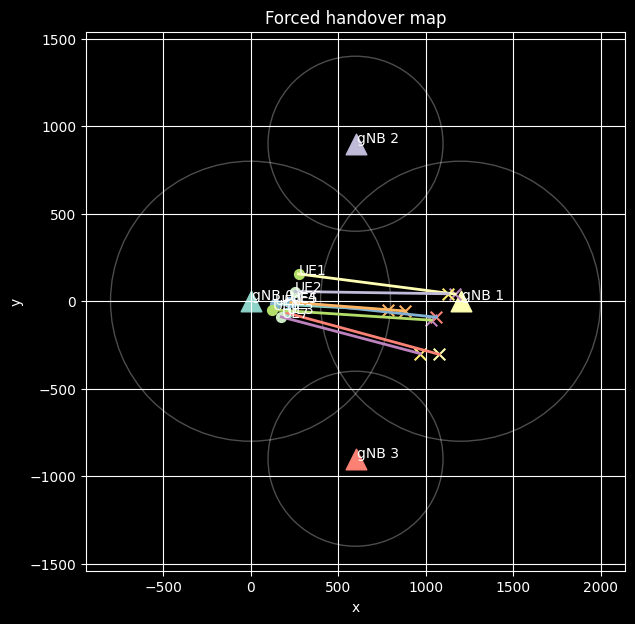

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=220, marker="^")
    ax.add_patch(Circle((gnb.x, gnb.y), gnb.coverage_radius, fill=False, alpha=0.3))
    ax.text(gnb.x + 10, gnb.y + 10, f"gNB {gnb.id}")

for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")
    ax.plot(d["x"], d["y"], linewidth=2)
    ax.scatter(d["x"].iloc[0], d["y"].iloc[0], s=50)
    ax.scatter(d["x"].iloc[-1], d["y"].iloc[-1], s=70, marker="x")
    ax.text(d["x"].iloc[0], d["y"].iloc[0], f"UE{ue_id}")

ax.set_title("Forced handover map")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)
plt.show()

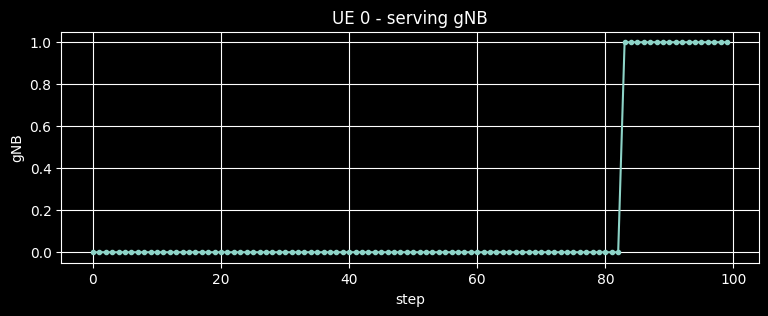

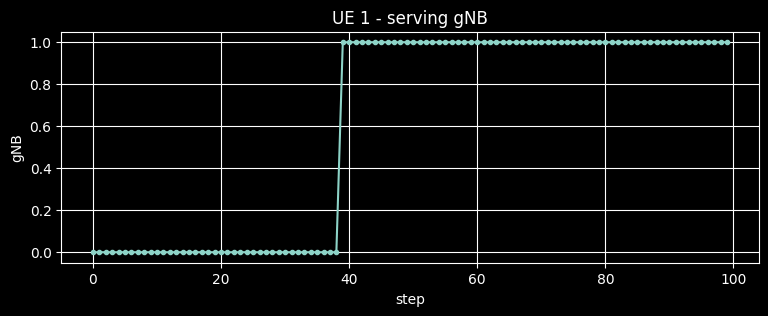

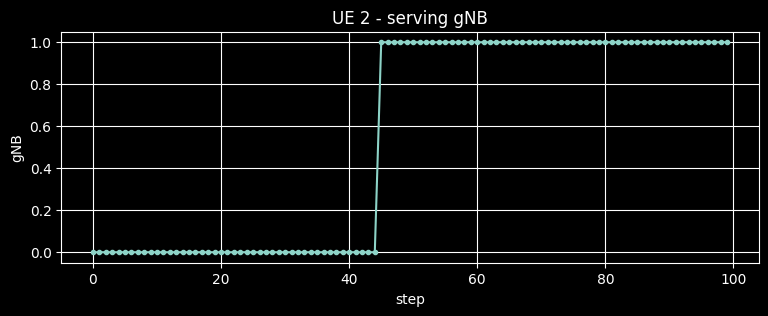

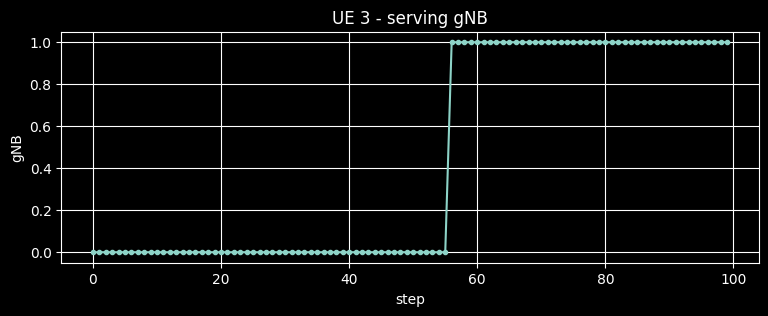

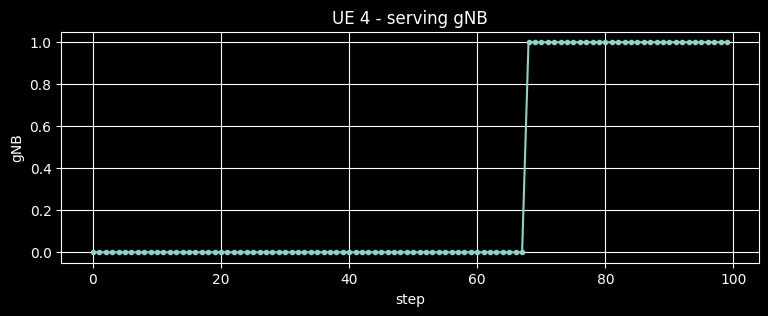

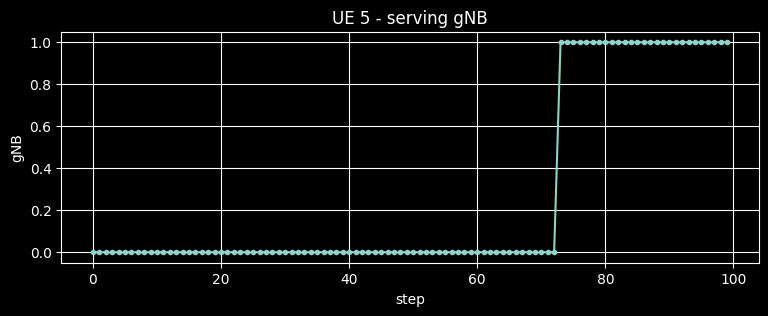

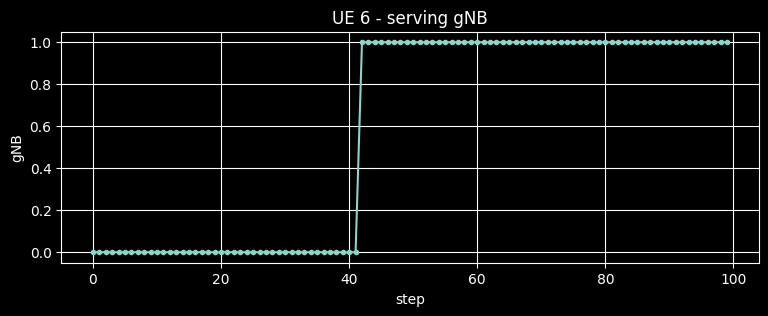

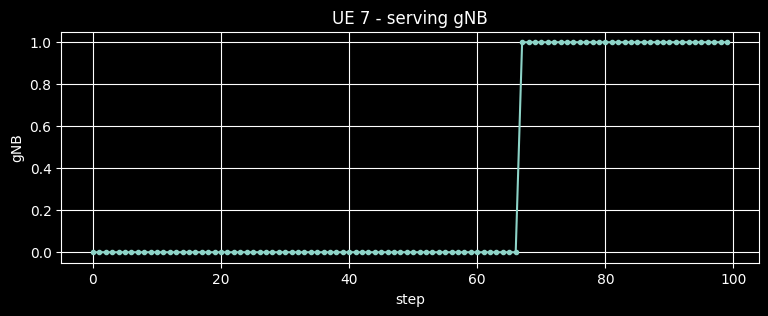

In [10]:
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    plt.figure(figsize=(9, 3))
    plt.plot(d["step"], d["serving_gnb"], marker="o", markersize=3)
    plt.title(f"UE {ue_id} - serving gNB")
    plt.xlabel("step")
    plt.ylabel("gNB")
    plt.grid(True)
    plt.show()

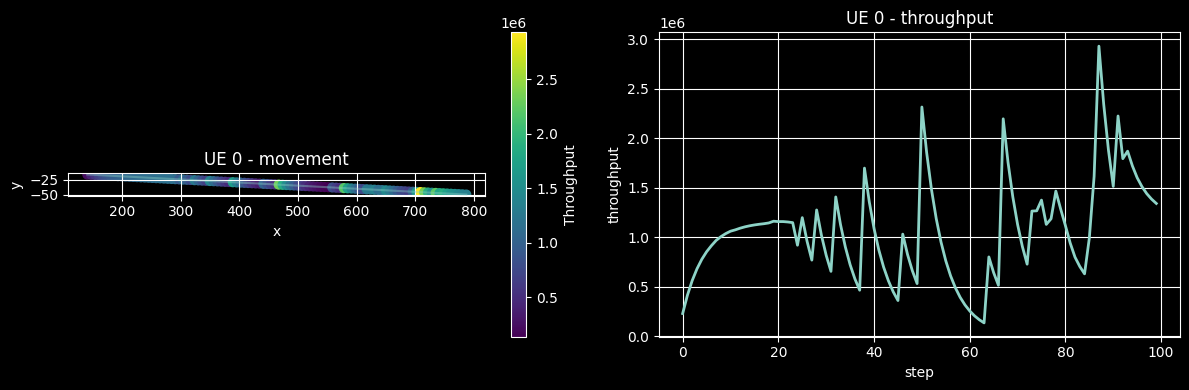

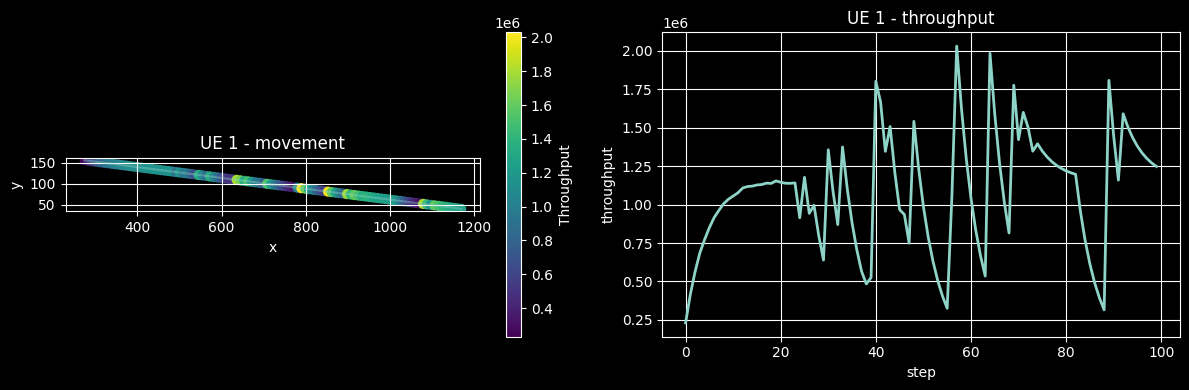

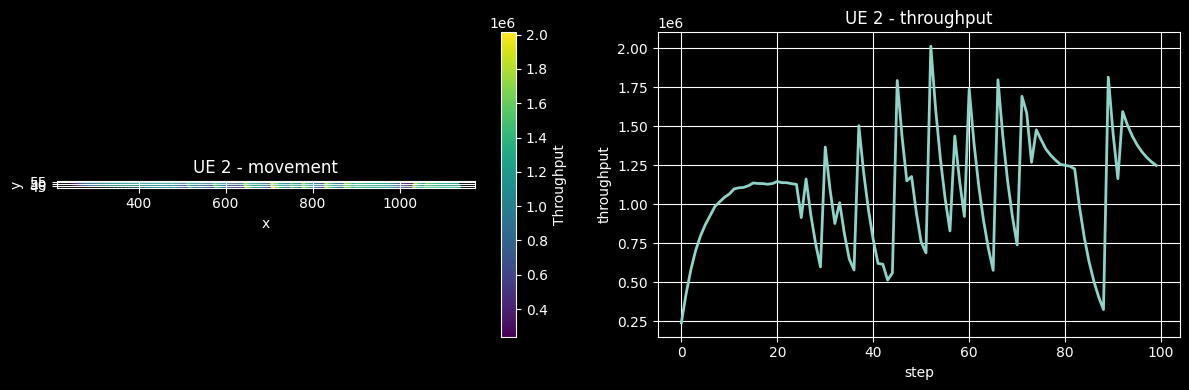

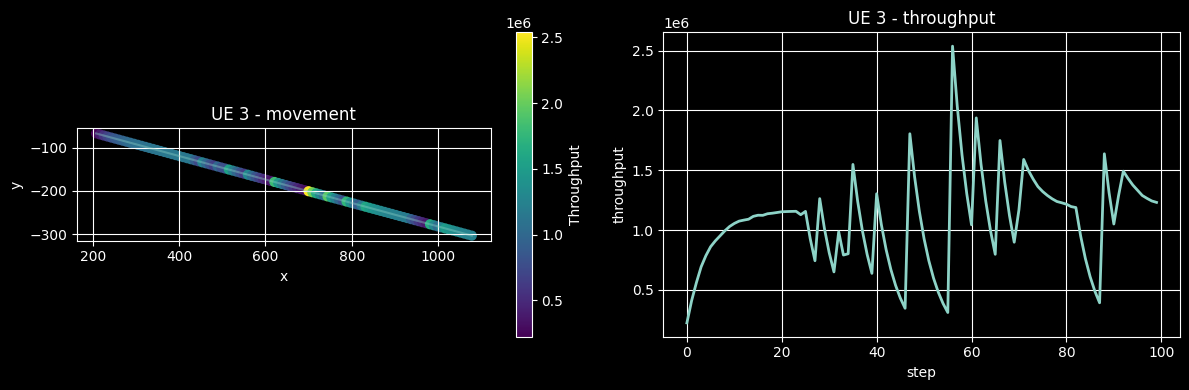

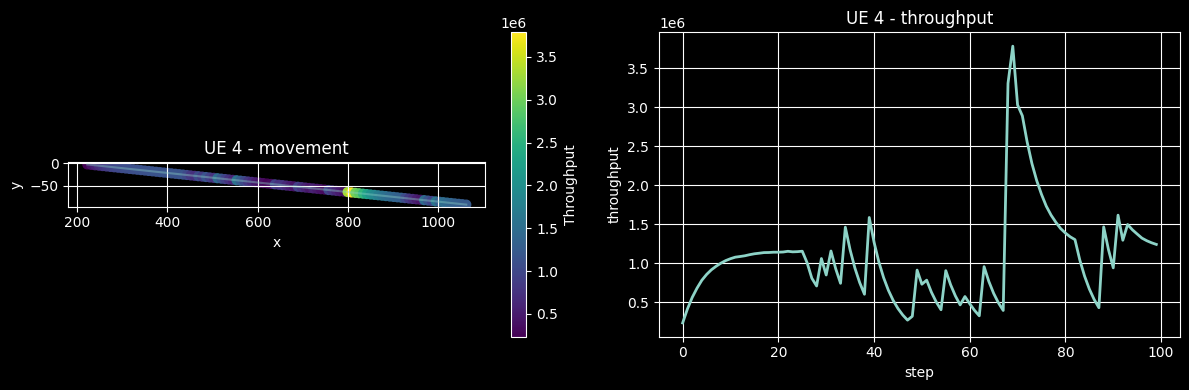

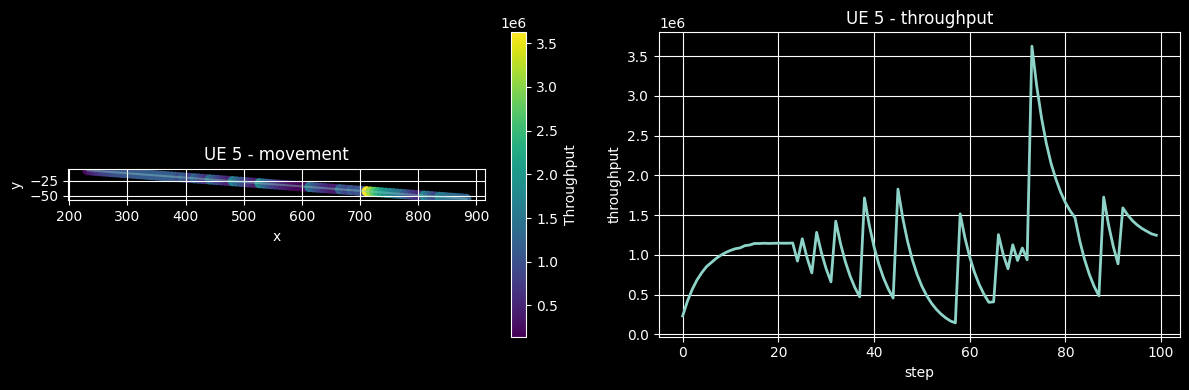

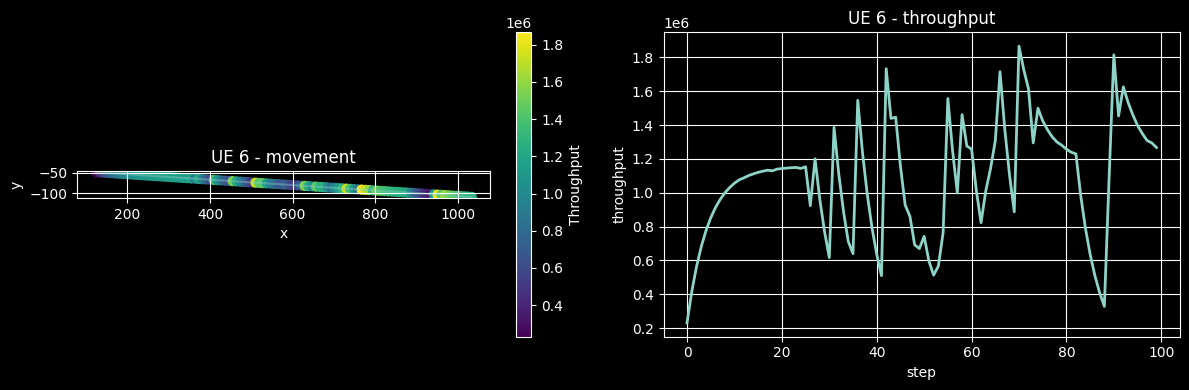

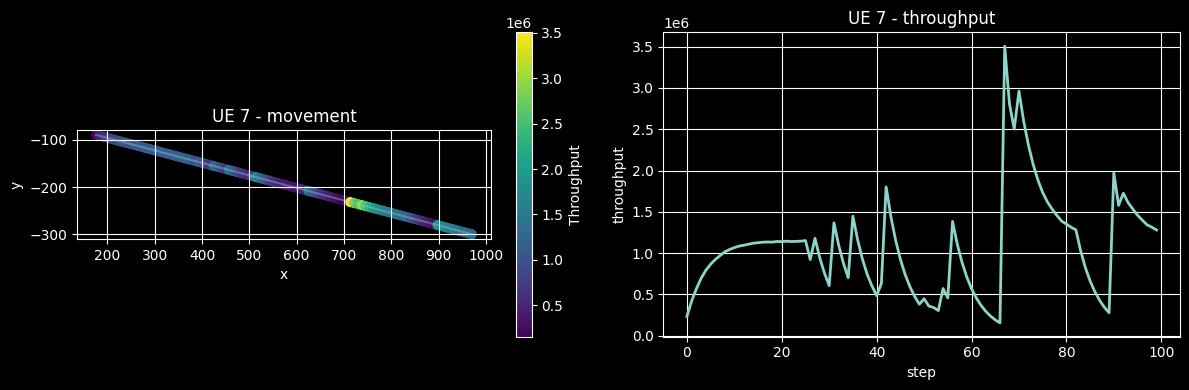

In [11]:
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sc = axes[0].scatter(
        d["x"], d["y"],
        c=d["throughput"],
        cmap="viridis",
        s=40
    )
    axes[0].plot(d["x"], d["y"], alpha=0.4)
    axes[0].set_title(f"UE {ue_id} - movement")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")
    axes[0].grid(True)
    plt.colorbar(sc, ax=axes[0], label="Throughput")

    axes[1].plot(d["step"], d["throughput"], linewidth=2)
    axes[1].set_title(f"UE {ue_id} - throughput")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("throughput")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [12]:
ue_id = 0
d = df[df["ue_id"] == ue_id].sort_values("step")

print("Rows for UE 8:", len(d))
d.head()

Rows for UE 8: 100


,step,ue_id,x,y,vx,vy,serving_gnb,connected,sinr,snr,interference_dbm,queue,throughput,prbs,acted_ue_id,next_control_ue_id,reward
0,0,0,140.687205,-15.725955,6.530393,-0.345908,0,1,39.519742,39.519742,NaN,0.0,230855.364987,8.0,2,2,0.243324
8,1,0,147.217597,-16.071864,6.530393,-0.345908,0,1,29.199836,29.199836,NaN,0.0,416079.136031,8.0,2,3,0.303823
16,2,0,153.747990,-16.417772,6.530393,-0.345908,0,1,32.766875,32.766875,NaN,0.0,564388.057334,8.0,3,3,1.134737
24,3,0,160.278383,-16.763681,6.530393,-0.345908,0,1,34.510519,34.510519,NaN,0.0,683120.797772,8.0,3,2,1.163505
32,4,0,166.808776,-17.109589,6.530393,-0.345908,0,1,38.502575,38.502575,NaN,0.0,778313.736072,8.0,2,7,0.425862


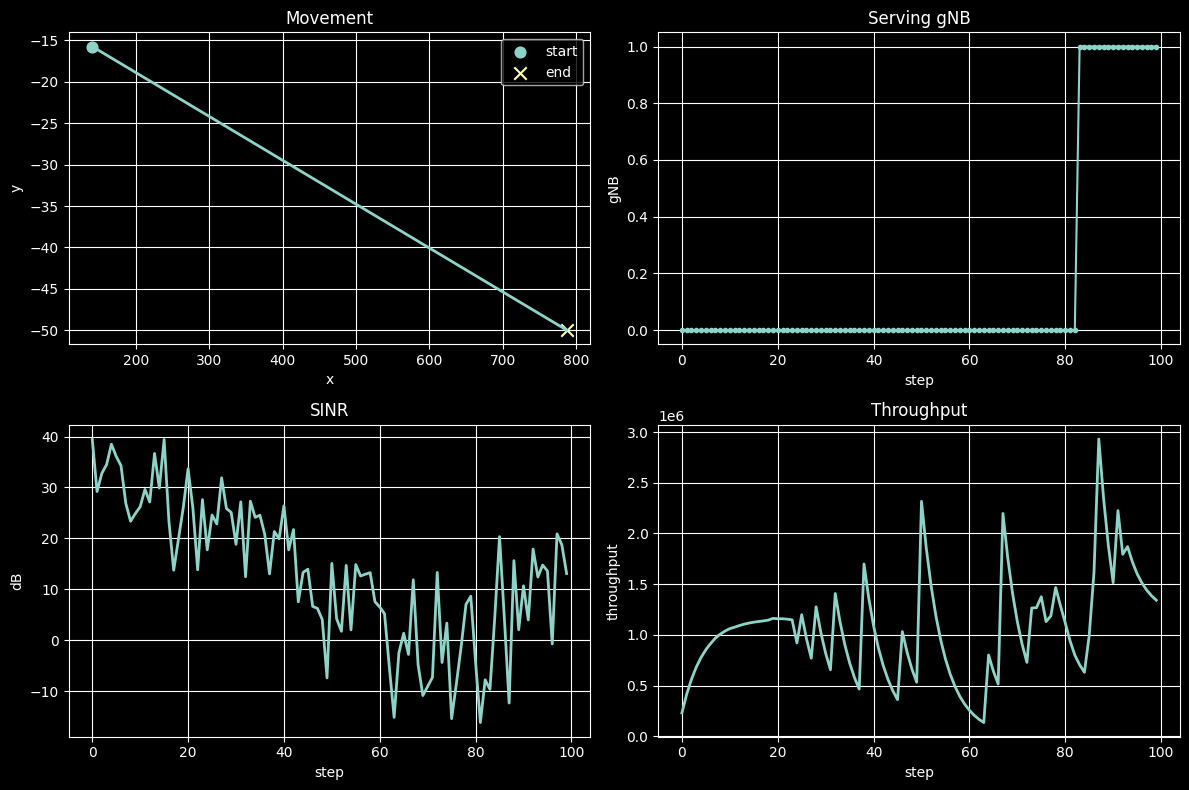

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(d["x"], d["y"], linewidth=2)
axes[0, 0].scatter(d["x"].iloc[0], d["y"].iloc[0], s=60, label="start")
axes[0, 0].scatter(d["x"].iloc[-1], d["y"].iloc[-1], s=80, marker="x", label="end")
axes[0, 0].set_title("Movement")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(d["step"], d["serving_gnb"], marker="o", markersize=3)
axes[0, 1].set_title("Serving gNB")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("gNB")
axes[0, 1].grid(True)

axes[1, 0].plot(d["step"], d["sinr"], linewidth=2)
axes[1, 0].set_title("SINR")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("dB")
axes[1, 0].grid(True)

axes[1, 1].plot(d["step"], d["throughput"], linewidth=2)
axes[1, 1].set_title("Throughput")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("throughput")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

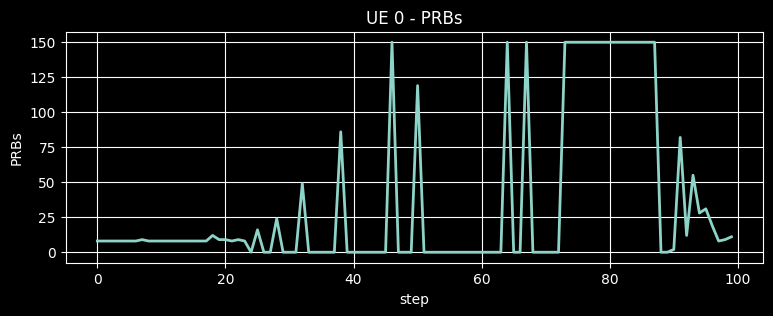

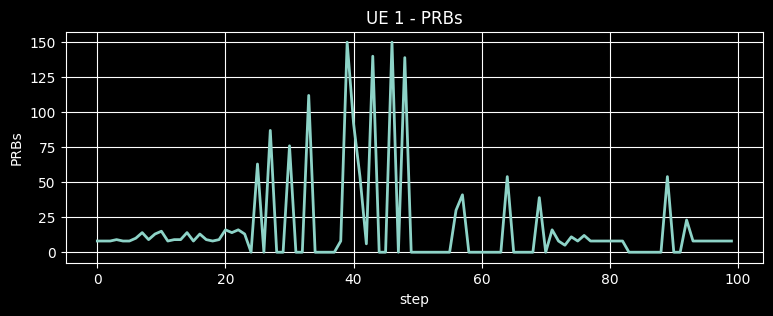

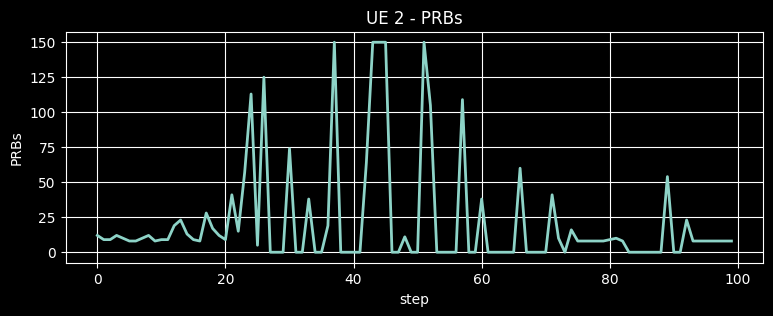

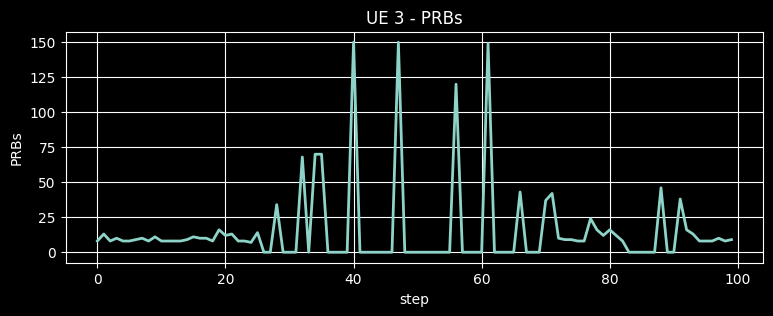

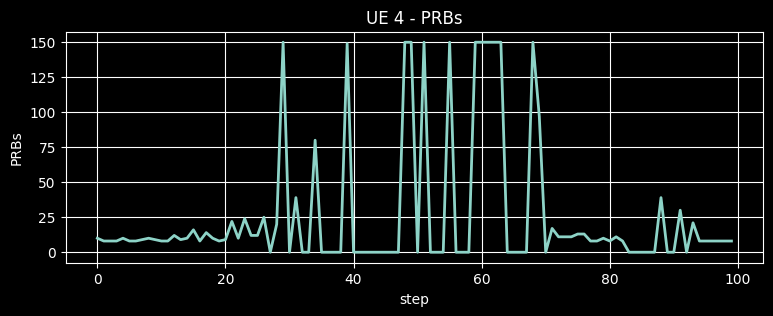

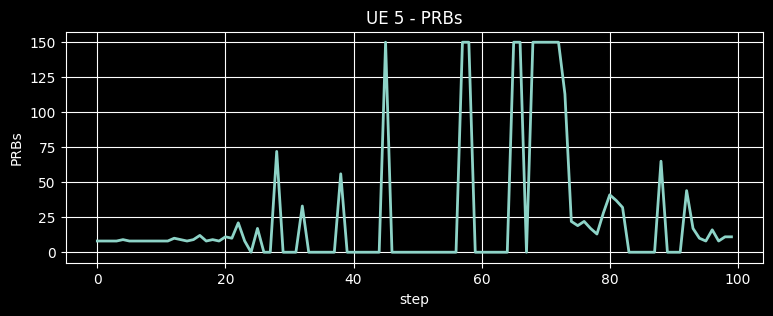

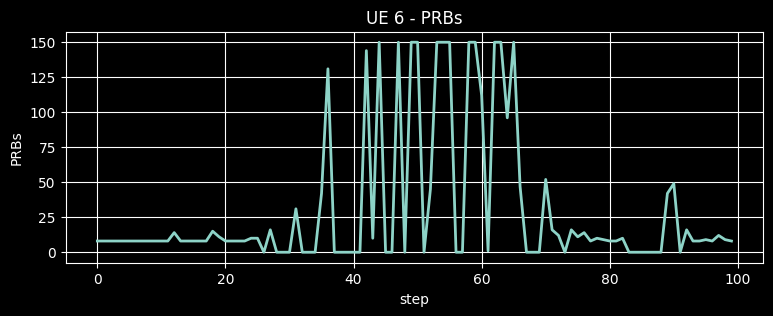

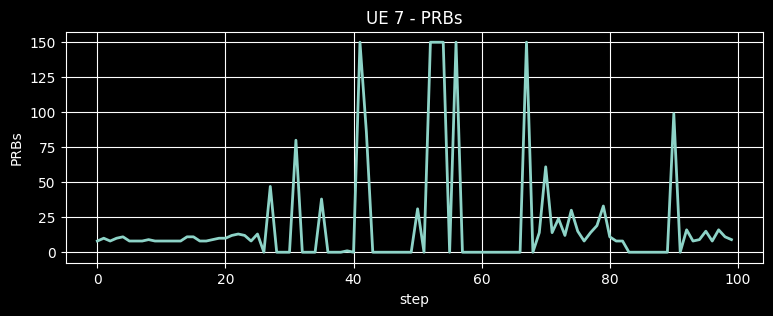

In [14]:
for ue_id in sorted(df["ue_id"].unique()):
    d = df[df["ue_id"] == ue_id].sort_values("step")

    plt.figure(figsize=(9, 3))
    plt.plot(d["step"], d["prbs"], linewidth=2)
    plt.title(f"UE {ue_id} - PRBs")
    plt.xlabel("step")
    plt.ylabel("PRBs")
    plt.grid(True)
    plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Sum PRBs of all UEs attached to each gNB at each step
df_gnb_prb = (
    df.groupby(["step", "serving_gnb"], as_index=False)["prbs"]
      .sum()
      .rename(columns={"serving_gnb": "gnb_id", "prbs": "used_prbs"})
)

# Make sure every (step, gNB) pair exists
all_steps = sorted(df["step"].unique())
all_gnbs = sorted([gnb.id for gnb in env.gnbs])

full_index = pd.MultiIndex.from_product([all_steps, all_gnbs], names=["step", "gnb_id"])
df_gnb_prb = (
    df_gnb_prb.set_index(["step", "gnb_id"])
              .reindex(full_index, fill_value=0)
              .reset_index()
)

df_gnb_prb.head()

,step,gnb_id,used_prbs
0,0,0,70.0
1,0,1,0.0
2,0,2,0.0
3,0,3,0.0
4,1,0,72.0


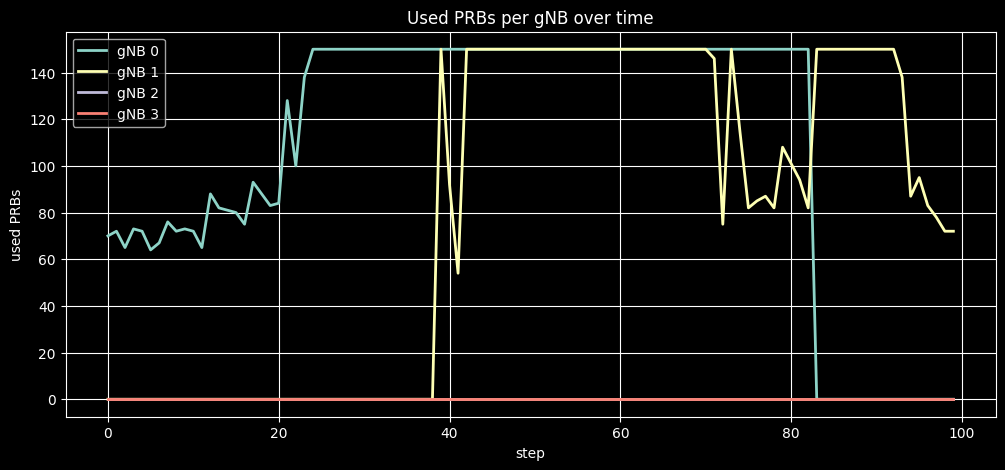

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

for gnb_id in sorted(df_gnb_prb["gnb_id"].unique()):
    d = df_gnb_prb[df_gnb_prb["gnb_id"] == gnb_id]
    ax.plot(d["step"], d["used_prbs"], linewidth=2, label=f"gNB {gnb_id}")

ax.set_title("Used PRBs per gNB over time")
ax.set_xlabel("step")
ax.set_ylabel("used PRBs")
ax.grid(True)
ax.legend()
plt.show()

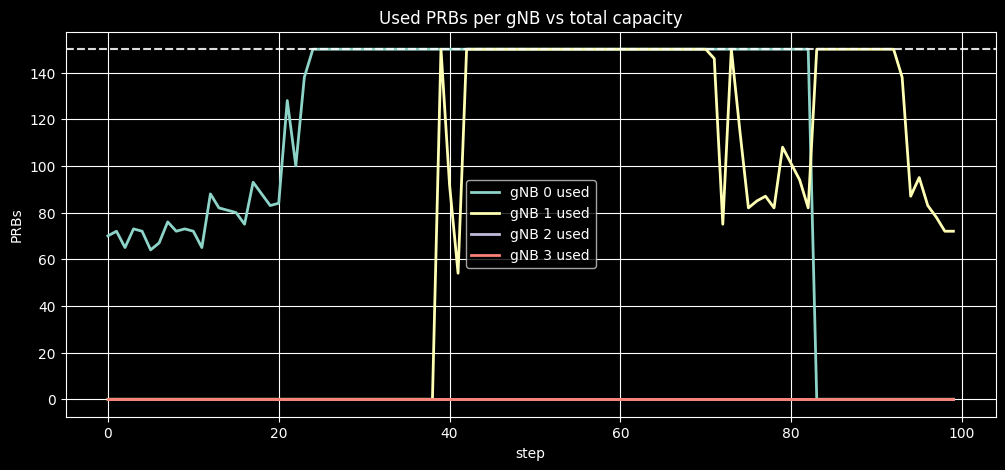

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

for gnb in env.gnbs:
    d = df_gnb_prb[df_gnb_prb["gnb_id"] == gnb.id]
    ax.plot(d["step"], d["used_prbs"], linewidth=2, label=f"gNB {gnb.id} used")
    ax.axhline(gnb.n_prbs, linestyle="--", alpha=0.4)

ax.set_title("Used PRBs per gNB vs total capacity")
ax.set_xlabel("step")
ax.set_ylabel("PRBs")
ax.grid(True)
ax.legend()
plt.show()

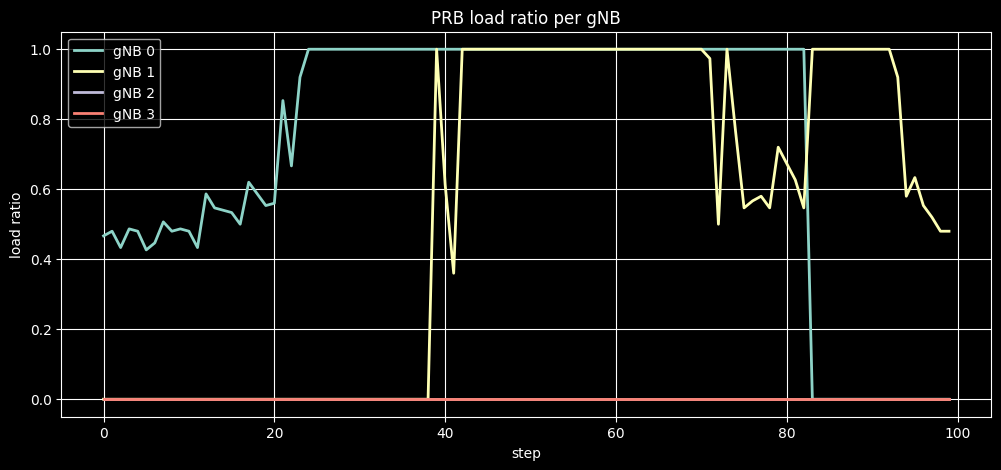

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

for gnb in env.gnbs:
    d = df_gnb_prb[df_gnb_prb["gnb_id"] == gnb.id].copy()
    d["load_ratio"] = d["used_prbs"] / gnb.n_prbs
    ax.plot(d["step"], d["load_ratio"], linewidth=2, label=f"gNB {gnb.id}")

ax.set_title("PRB load ratio per gNB")
ax.set_xlabel("step")
ax.set_ylabel("load ratio")
ax.grid(True)
ax.legend()
plt.show()

# test stupid idea

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Fresh env
# -----------------------------
rng = np.random.default_rng(0)
gnb_configs = scenario_to_gnb_configs(scenario_4gnb_forced_handover)

env = create_env(
    rng=rng,
    n=1,
    multi_gnb=True,
    gnb_configs=gnb_configs,
    slots_per_step=10,
    coverage_radius=800,
    handover_hysteresis=0.0,
    handover_ttt=1,
    verbose=False,
    step_dt=1.0,
    max_episode_steps=200,
)

# -----------------------------
# 2) Add background UEs to load gNB 1
# -----------------------------
# These UEs stay near gNB 1 and create load there
for i in range(8):
    x = rng.uniform(1050, 1300)
    y = rng.uniform(-120, 120)
    env.add_ue(
        x=float(x),
        y=float(y),
        vx=0.0,
        vy=0.0,
        slice_type="eMBB",
        bit_rate=2_000_000.0,
    )

# Add one test UE near gNB 0, moving toward gNB 1
test_ue_id = env.add_ue(
    x=180.0,
    y=0.0,
    vx=10.0,
    vy=0.0,
    slice_type="eMBB",
    bit_rate=1_500_000.0,
)

obs, info = env.reset(seed=123)

# -----------------------------
# 3) Warm-up to build queues/load
# -----------------------------
for _ in range(15):
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    if terminated or truncated:
        break

# -----------------------------
# 4) Rollout and force HO when gNB 1 becomes candidate
# -----------------------------
rows = []
handover_step = None
forced_target = 1

for step in range(80):
    test_ue = env.get_ue(test_ue_id)

    # Current candidates for the controlled UE only matter if it is selected.
    # We still log the radio state of the test UE every step.
    sinr_per_gnb = {gnb.id: env._get_sinr_db(gnb, test_ue) for gnb in env.gnbs}

    # Default action: stay
    action = 0

    # If the controlled UE is our test UE, try to force HO to gNB 1 if candidate exists
    if env._current_control_ue_id == test_ue_id:
        candidates = env.get_candidate_gnbs(test_ue, top_k=env.max_candidates)
        serving = env._get_gnb_by_id(test_ue.serving_gnb) if test_ue.serving_gnb is not None else None
        alt_candidates = [g for g in candidates if serving is None or g.id != serving.id]
        alt_ids = [g.id for g in alt_candidates]

        if forced_target in alt_ids:
            action = alt_ids.index(forced_target) + 1

    obs, reward, terminated, truncated, info = env.step(action)

    test_ue = env.get_ue(test_ue_id)
    metrics = env.get_ue_radio_metrics(test_ue_id)

    # gNB 1 load snapshot
    gnb1_users = [ue for ue in env.get_all_ues() if ue.serving_gnb == forced_target]
    gnb1_used_prbs = sum(int(max(ue.prbs, 0)) for ue in gnb1_users)
    gnb1_total_prbs = env._get_gnb_by_id(forced_target).n_prbs

    if handover_step is None and info.get("acted_ue_id") == test_ue_id:
        before = info.get("serving_gnb_before")
        after = info.get("serving_gnb_after")
        if before != after and after == forced_target:
            handover_step = step

    rows.append({
        "step": step,
        "ue_id": int(test_ue.id),
        "x": float(test_ue.x),
        "y": float(test_ue.y),
        "serving_gnb": -1 if test_ue.serving_gnb is None else int(test_ue.serving_gnb),
        "throughput": float(test_ue.th),
        "queue": float(test_ue.queue),
        "wait_time": float(test_ue.wait_time),
        "prbs": float(test_ue.prbs),
        "sinr": float(metrics["sinr_db"]) if np.isfinite(metrics["sinr_db"]) else np.nan,
        "snr": float(metrics["snr_db"]) if np.isfinite(metrics["snr_db"]) else np.nan,
        "reward": float(reward),
        "acted_ue_id": info.get("acted_ue_id"),
        "serving_before": info.get("serving_gnb_before"),
        "serving_after": info.get("serving_gnb_after"),
        "gnb1_used_prbs": gnb1_used_prbs,
        "gnb1_total_prbs": gnb1_total_prbs,
        "gnb1_load_ratio": gnb1_used_prbs / gnb1_total_prbs,
        "sinr_gnb_0": sinr_per_gnb.get(0, np.nan),
        "sinr_gnb_1": sinr_per_gnb.get(1, np.nan),
        "sinr_gnb_2": sinr_per_gnb.get(2, np.nan),
        "sinr_gnb_3": sinr_per_gnb.get(3, np.nan),
    })

    if terminated or truncated:
        break

df_test = pd.DataFrame(rows)
print("handover_step =", handover_step)
display(df_test.head())
display(df_test.tail())

handover_step = 7


,step,ue_id,x,y,serving_gnb,throughput,queue,wait_time,prbs,sinr,...,acted_ue_id,serving_before,serving_after,gnb1_used_prbs,gnb1_total_prbs,gnb1_load_ratio,sinr_gnb_0,sinr_gnb_1,sinr_gnb_2,sinr_gnb_3
0,0,8,340.0,0.0,0,1.680063e+06,0.0,16.0,12.0,21.025407,...,8,0,0,128,150,0.853333,10.084744,-inf,-inf,-inf
1,1,8,350.0,0.0,0,1.687712e+06,0.0,17.0,13.0,23.958438,...,0,1,1,128,150,0.853333,11.943529,-inf,-inf,-inf
2,2,8,360.0,0.0,0,1.697105e+06,0.0,18.0,15.0,24.985684,...,0,1,1,128,150,0.853333,13.433440,-inf,-inf,-inf
3,3,8,370.0,0.0,0,1.701502e+06,0.0,19.0,18.0,17.711511,...,8,0,0,128,150,0.853333,19.469930,-inf,-inf,-inf
4,4,8,380.0,0.0,0,1.701676e+06,0.0,20.0,17.0,19.524924,...,8,0,0,128,150,0.853333,21.064052,-inf,-inf,-inf


,step,ue_id,x,y,serving_gnb,throughput,queue,wait_time,prbs,sinr,...,acted_ue_id,serving_before,serving_after,gnb1_used_prbs,gnb1_total_prbs,gnb1_load_ratio,sinr_gnb_0,sinr_gnb_1,sinr_gnb_2,sinr_gnb_3
75,75,8,1090.0,0.0,1,1.593022e+06,52391922.0,91.0,0.0,39.257657,...,6,1,1,150,150,1.0,-inf,39.490275,-inf,-inf
76,76,8,1100.0,0.0,1,1.275867e+06,68874976.0,92.0,0.0,40.000000,...,2,1,1,150,150,1.0,-inf,40.000000,-inf,-inf
77,77,8,1110.0,0.0,1,2.750732e+06,0.0,93.0,60.0,33.441211,...,8,1,1,150,150,1.0,-inf,26.774840,-inf,-inf
78,78,8,1120.0,0.0,1,2.202597e+06,16500000.0,94.0,0.0,40.000000,...,3,1,1,150,150,1.0,-inf,40.000000,-inf,-inf
79,79,8,1130.0,0.0,1,1.765343e+06,32907052.0,95.0,0.0,40.000000,...,6,1,1,150,150,1.0,-inf,40.000000,-inf,-inf


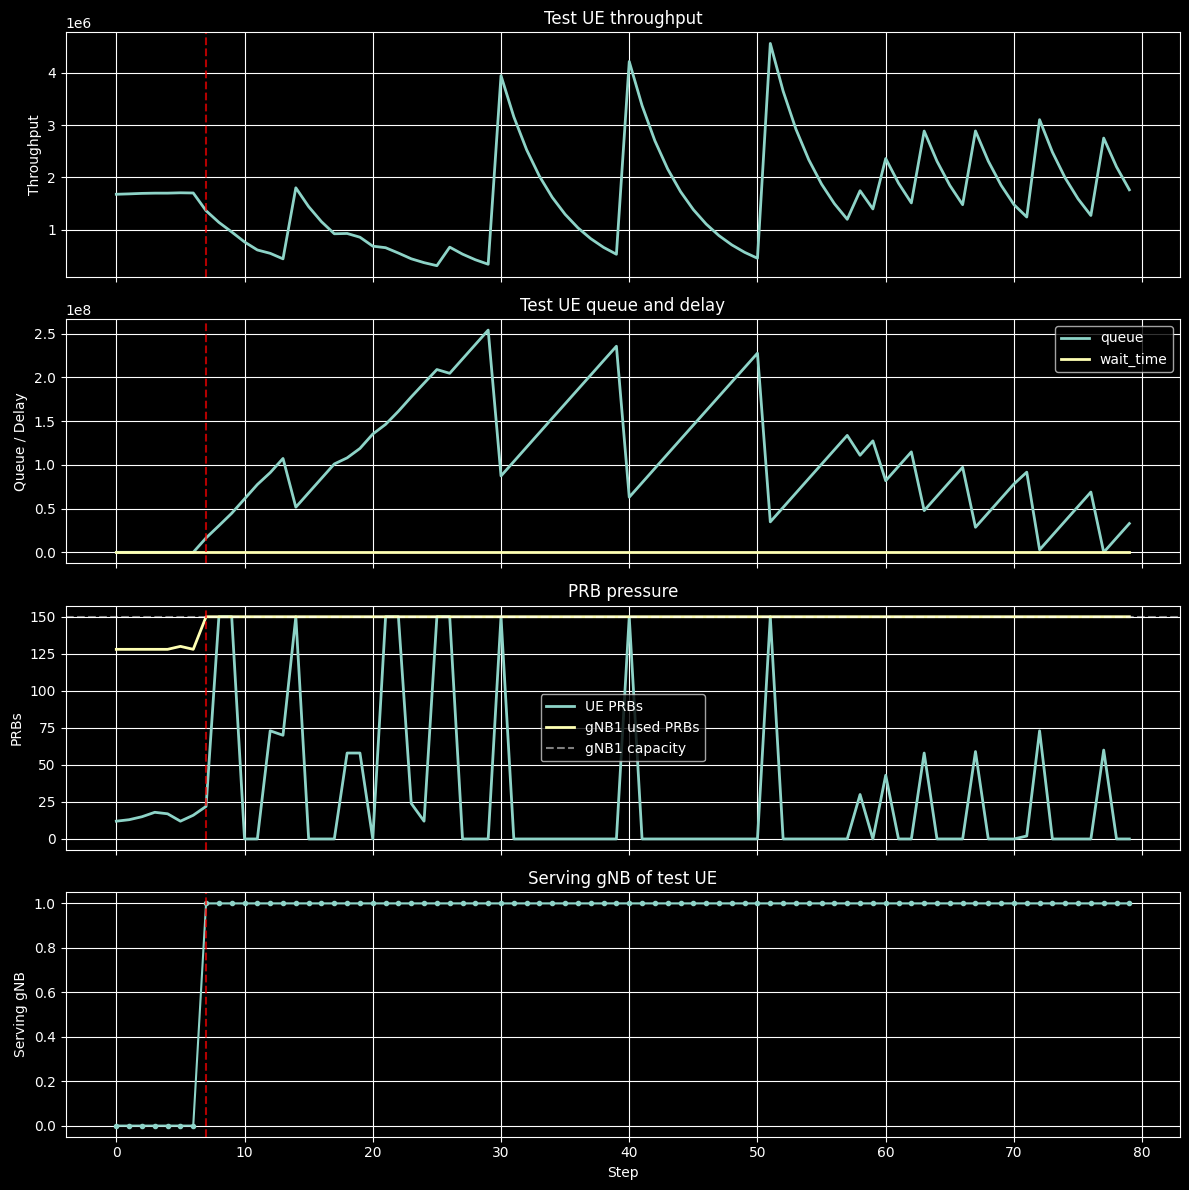

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df_test["step"], df_test["throughput"], linewidth=2)
axes[0].set_ylabel("Throughput")
axes[0].set_title("Test UE throughput")
axes[0].grid(True)

axes[1].plot(df_test["step"], df_test["queue"], linewidth=2, label="queue")
axes[1].plot(df_test["step"], df_test["wait_time"], linewidth=2, label="wait_time")
axes[1].set_ylabel("Queue / Delay")
axes[1].set_title("Test UE queue and delay")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df_test["step"], df_test["prbs"], linewidth=2, label="UE PRBs")
axes[2].plot(df_test["step"], df_test["gnb1_used_prbs"], linewidth=2, label="gNB1 used PRBs")
axes[2].axhline(df_test["gnb1_total_prbs"].iloc[0], linestyle="--", alpha=0.5, label="gNB1 capacity")
axes[2].set_ylabel("PRBs")
axes[2].set_title("PRB pressure")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(df_test["step"], df_test["serving_gnb"], marker="o", markersize=3)
axes[3].set_ylabel("Serving gNB")
axes[3].set_xlabel("Step")
axes[3].set_title("Serving gNB of test UE")
axes[3].grid(True)

if handover_step is not None:
    for ax in axes:
        ax.axvline(handover_step, color="red", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

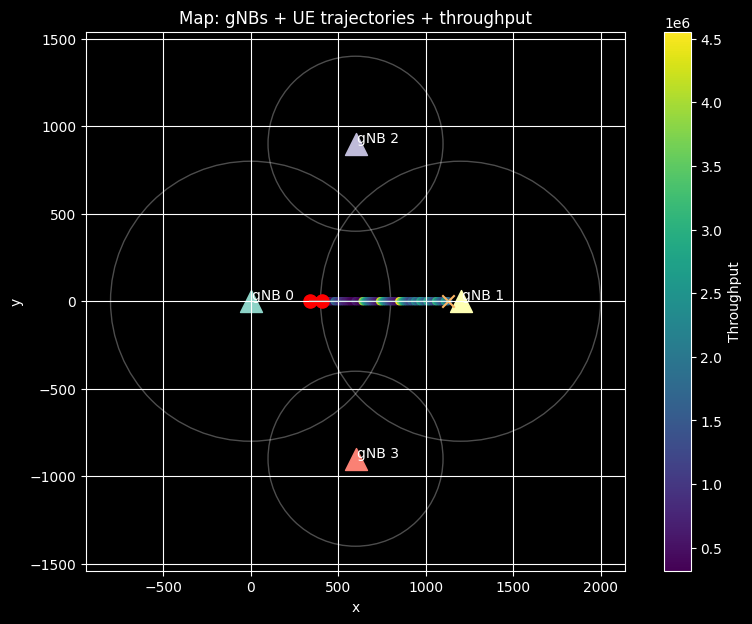

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10, 7))

# -------------------------
# Plot gNBs
# -------------------------
for gnb in env.gnbs:
    ax.scatter(gnb.x, gnb.y, s=250, marker="^")
    ax.add_patch(
        Circle((gnb.x, gnb.y), gnb.coverage_radius, fill=False, alpha=0.3)
    )
    ax.text(gnb.x + 10, gnb.y + 10, f"gNB {gnb.id}", fontsize=10)

# -------------------------
# Plot UE trajectories
# -------------------------
for ue_id in sorted(df_test["ue_id"].unique()):
    d = df_test[df_test["ue_id"] == ue_id].sort_values("step")

    # color by throughput
    sc = ax.scatter(
        d["x"],
        d["y"],
        c=d["throughput"],
        cmap="viridis",
        s=25
    )

    ax.plot(d["x"], d["y"], alpha=0.3)

    # start / end markers
    ax.scatter(d["x"].iloc[0], d["y"].iloc[0], s=60, label=f"UE {ue_id} start")
    ax.scatter(d["x"].iloc[-1], d["y"].iloc[-1], s=80, marker="x")

# -------------------------
# Mark handover points (test UE only)
# -------------------------
if "serving_gnb" in df_test.columns:
    for ue_id in sorted(df_test["ue_id"].unique()):
        d = df_test[df_test["ue_id"] == ue_id].sort_values("step")
        ho = d[d["serving_gnb"].diff() != 0]

        ax.scatter(
            ho["x"],
            ho["y"],
            color="red",
            s=90,
            marker="o",
            label=f"UE {ue_id} HO"
        )

# -------------------------
# Layout
# -------------------------
ax.set_title("Map: gNBs + UE trajectories + throughput")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True)

# colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Throughput")

plt.show()